In [1]:
import torch
from ultralytics.models.yolo import YOLO

torch.cuda.is_available()


True

In [2]:
torch.cuda.device_count()

1

In [ ]:
model = YOLO("yolo26n-seg.pt")

results_model = model.train(
    data="../data/yolo_seg_train.yml",
    epochs=100,
    imgsz=640,
)

In [3]:
model = YOLO("E:/Projects/tp_yolo/runs/segment/train6/weights/best.pt")

In [23]:
TEST_IMG = "../data/Test-TP-3.png"

results = model.predict(
    source=TEST_IMG,
    show=True,
    conf=0.25,
    device=0,
)

len(results)


image 1/1 e:\Projects\tp_yolo\notebooks\..\data\Test-TP-3.png: 416x640 1 tactile_paving, 58.1ms
Speed: 2.9ms preprocess, 58.1ms inference, 2.0ms postprocess per image at shape (1, 3, 416, 640)


1

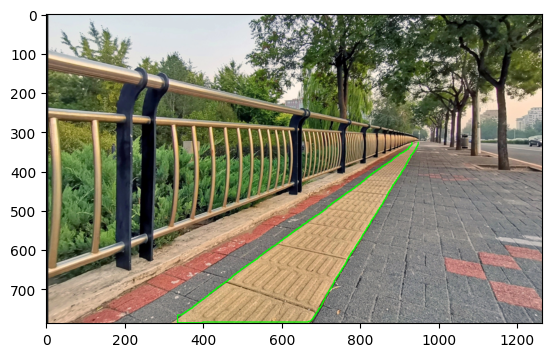

In [24]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(TEST_IMG)

for result in results:
    contour = result.masks.xy
    for cnt in contour:
        cnt = cnt.astype(int)
        cv2.polylines(img, [cnt], isClosed=False, color=(0, 255, 0), thickness=2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))